# <b><span style='color: #196f3d '>| PlantTraits2024:</span>  Tabular Model [Train]</b> 
Simple Tabular Data model based on [this notebook](https://www.kaggle.com/code/hdjojo/modified-planttraits2024-eda-training)
### <b><span style='color: #196f3d '>Table of Contents</span></b> <a class='anchor' id='top'></a>
<div style=" background-color: #ecf0f1 ; padding: 13px 13px; border-radius: 8px; color: white">
<li><a href="#import_libraries">Import Libraries</a></li>
<li><a href="#Configuration">Configuration</a></li>
<li><a href="#load_data">Load Data</a></li>
<li><a href="#outlier_removal">Outlier Removal</a></li>
<li><a href="#model">Model</a></li>
<li><a href="#train">Train Model</a></li>
<li><a href="#train">Score</a></li>
    
</div>

# <b><span style='color: #196f3d '>|</span> Import Libraries</b><a class='anchor' id='import_libraries'></a> [↑](#top) 

***

In [1]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import pytorch_lightning as pl

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import lightgbm as lgb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# <b><span style='color: #196f3d '>|</span> Configuration</b><a class='anchor' id='Configuration'></a> [↑](#top) 

***

In [2]:
class CFG:
    TARGET_COLUMNS = ['X4_mean', 'X11_mean', 'X18_mean', 'X50_mean', 'X26_mean', 'X3112_mean'] #don't change order 
    AUX_TARGET_COLUMNS = ['X4_sd', 'X11_sd', 'X18_sd', 'X50_sd', 'X26_sd', 'X3112_sd']

# Set base path
BASE_PATH = "/kaggle/input/planttraits2024"
DATAFRAME_PATH = "/kaggle/input/planttraits2024-dataframes"

# <b><span style='color: #196f3d '>|</span> Helper Functions</b><a class='anchor' id='Configuration'></a> [↑](#top) 

***

In [3]:
def plot_data(df):
    plt.figure(figsize=(15, 3))

    # Setting up a grid of plots with 2 columns
    n_cols = 6
    n_rows = len(CFG.TARGET_COLUMNS) // n_cols + (len(CFG.TARGET_COLUMNS) % n_cols > 0)

    for i, col in enumerate(CFG.TARGET_COLUMNS):
        plt.subplot(n_rows, n_cols, i+1)
        sns.kdeplot(df[col], bw_adjust=0.5, fill=False, color='blue')
        plt.title(f'Distribution of {col}')
        plt.xlabel('Value')
        plt.ylabel('Density')

    plt.tight_layout()
    plt.show()
    
def apply_log_scale(data_df, columns):
    """Log scales the provided columns of the input dataframe if their also in log_scale_columns"""
    data_array = data_df[columns].to_numpy(dtype=np.float32)
    for idx, col in enumerate(columns):
        data_array[:, idx] = np.log10(data_array[:, idx])
    return data_array

# <b><span style='color: #196f3d '>|</span> Load Data</b><a class='anchor' id='load_data'></a> [↑](#top) 

In [4]:
df = pd.read_csv(f'{BASE_PATH}/train.csv')
test_df = pd.read_csv(f'{BASE_PATH}/test.csv')

#drop auxillary collumns
df = df.drop(columns=CFG.AUX_TARGET_COLUMNS)

#STORE TARGET COLLUMNS
CFG.FEATURE_COLS = test_df.columns[1:].tolist() 

# <b><span style='color: #196f3d '>|</span> Outlier Removal</b><a class='anchor' id='outlier_removal'></a> [↑](#top) 

Our training data contains quite some bad outliers. According to the competition host, [these outliers have been removed from the test set](https://www.kaggle.com/competitions/planttraits2024/discussion/483414), however, they remain still in our training and validation dataframe. So before splitting into training and validation, we should remove these outliers.

In [5]:
#REMOVE OUTLIERS FROM TARGETS
for column in (CFG.TARGET_COLUMNS):
    upper_quantile = df[column].quantile(0.98)
    df = df[(df[column] < upper_quantile)]
    df = df[(df[column] > 0)] #remove negative values 

# <b><span style='color: #196f3d '>|</span> Preprocessing</b><a class='anchor' id='preprocessing'></a> [↑](#top) 
First we normalize and store the training **features**. We will use the following notation:
- **(Main) Features:** The images
- **Auxillary Features:** The Tabular data 
- **(Main) Labels:** The means of the 6 plant trait features.
- **Auxillary Labels:** The stds of the 6 plant trait features.

/tmp/ipykernel_18/1138111326.py:2: RuntimeWarning: invalid value encountered in log1p
  train_tab_features = np.log1p(df[CFG.FEATURE_COLS].values)
/tmp/ipykernel_18/1138111326.py:3: RuntimeWarning: invalid value encountered in log1p
  test_tab_features = np.log1p(test_df[CFG.FEATURE_COLS].values)


Distributions before normalizing:


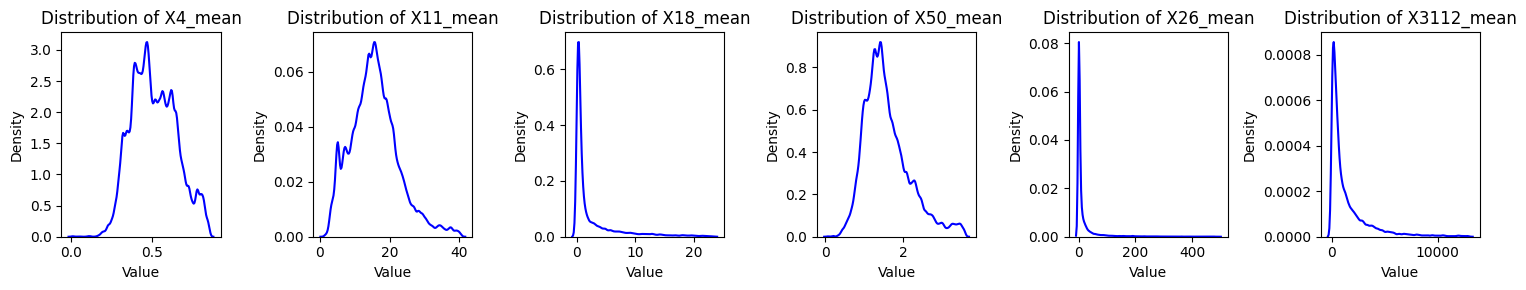

Distributions after normalizing:


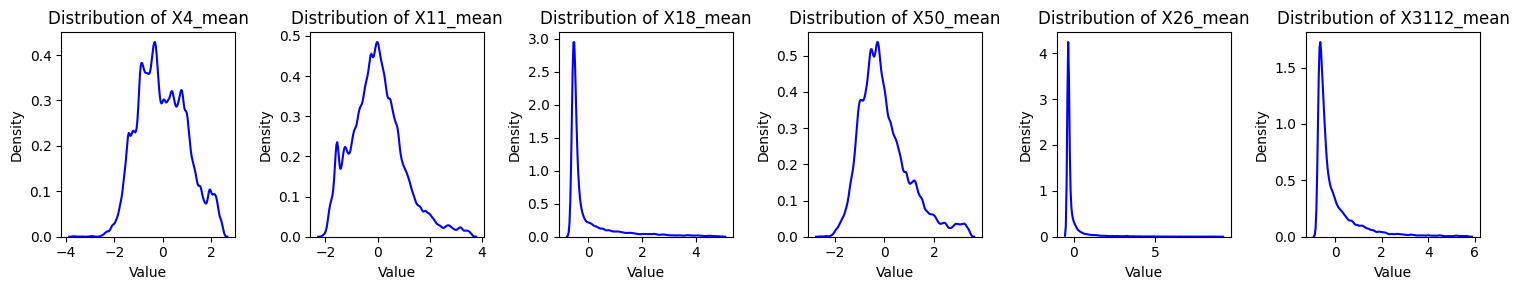

In [6]:
# LOG-SCALE FEATURES
train_tab_features = np.log1p(df[CFG.FEATURE_COLS].values)
test_tab_features = np.log1p(test_df[CFG.FEATURE_COLS].values)

# Normalize and store tabular features
FEATURE_SCALER = StandardScaler()
train_tab_features = FEATURE_SCALER.fit_transform(train_tab_features)
test_tab_features = FEATURE_SCALER.transform(test_tab_features)

# NORMALIZE TARGETS
TARGET_SCALER = StandardScaler()
train_targets = TARGET_SCALER.fit_transform(df[CFG.TARGET_COLUMNS])

print('Distributions before normalizing:')
plot_data(df[CFG.TARGET_COLUMNS])

print('Distributions after normalizing:')
plot_data(pd.DataFrame(train_targets, columns=CFG.TARGET_COLUMNS))

# <b><span style='color: #196f3d '>|</span> Model</b><a class='anchor' id='model'></a> [↑](#top) 

***


In [ ]:
# Initialize the LightGBM Regressor
lgb_regressor = lgb.LGBMRegressor(objective='regression', n_estimators=150, learning_rate=0.05, max_depth=10, num_leaves=512,
                                  subsample=0.8, colsample_bytree=0.8, n_jobs=-1, verbose=-1)

# Wrap LightGBM with MultiOutputRegressor to handle multi-output regression
multi_output_model = MultiOutputRegressor(lgb_regressor)

# Perform KFold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_score = -np.inf
best_model = None

print("\nDoing cross-validation scoring...")
for train_index, val_index in kf.split(train_tab_features):
    X_train, X_val = train_tab_features[train_index], train_tab_features[val_index]
    y_train, y_val = train_targets[train_index], train_targets[val_index]
    
    # Train model on the training fold
    multi_output_model.fit(X_train, y_train)
    
    # Predict on the validation fold
    y_pred = multi_output_model.predict(X_val)
    
    # Compute the R^2 score
    score = r2_score(y_val, y_pred, multioutput='uniform_average')
    print(f"Fold R^2 score: {score}")
    
    # Check if this is the best model so far
    if score > best_score:
        best_score = score
        best_model = multi_output_model

print(f"Best R^2 score across folds: {best_score}")

In [8]:
# Initialize the LightGBM Regressor
lgb_regressor = lgb.LGBMRegressor(objective='regression', n_estimators=137, learning_rate=0.019, max_depth=15, num_leaves=403,
                                  subsample = 0.770, colsample_bytree = 0.70, n_jobs=-1, verbose=-1)

# Wrap LightGBM with MultiOutputRegressor to handle multi-output regression
best_model = MultiOutputRegressor(lgb_regressor)

# Train model with all data
print("Training final model...")
best_model.fit(train_tab_features, train_targets) #Regardless of cross-validation, the final model is always trained on the entire dataset to maximize its predictive power.

Training final model...


MultiOutputRegressor(estimator=LGBMRegressor(colsample_bytree=0.7,
                                             learning_rate=0.019, max_depth=15,
                                             n_estimators=137, n_jobs=-1,
                                             num_leaves=403,
                                             objective='regression',
                                             subsample=0.77, verbose=-1))

In [ ]:
# HYPERPARAMETER SEARCH

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor

# Define the parameter distributions
param_distributions = {
    'estimator__n_estimators': randint(50, 200),
    'estimator__learning_rate': uniform(0.01, 0.1 - 0.01),  # Uniform distribution from 0.01 to 0.1
    'estimator__max_depth': randint(5, 20),
    'estimator__num_leaves': randint(31, 512),
    'estimator__subsample': uniform(0.5, 0.95 - 0.5),  # Uniform distribution from 0.5 to 0.95
    'estimator__colsample_bytree': uniform(0.5, 0.95 - 0.5)  # Uniform distribution from 0.5 to 0.95
}

# Initialize the LightGBM Regressor
lgb_regressor = lgb.LGBMRegressor(objective='regression', n_jobs=-1, verbose=-1)

# Wrap LightGBM with MultiOutputRegressor to handle multi-output regression
multi_output_model = MultiOutputRegressor(lgb_regressor)

# Set up the RandomizedSearchCV
random_search = RandomizedSearchCV(
    multi_output_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=3,  # Number of folds in cross-validation
    scoring='r2',  # Evaluation metric
    verbose=1,
    n_jobs=-1,  # Use all available cores
    random_state=42
)

# Fit the model using RandomizedSearchCV
print("\nPerforming random search...")
random_search.fit(train_tab_features, train_targets)

# Get the best model and parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best R^2 score from random search: {best_score}")


# <b><span style='color:#196f3d'>|</span> Inference</b><a class='anchor' id='inference'></a> [↑](#top) 

***

In [10]:
# Prepare submission dataframe
plot_df = pd.DataFrame({'id': test_df['id']}) #df to plot later
submission_df = pd.DataFrame({'id': test_df['id']})
target_cols = [x.replace("_mean", "") for x in CFG.TARGET_COLUMNS]

# Get predictions
predictions = best_model.predict(test_tab_features)

# Reverse the scaling
predictions = TARGET_SCALER.inverse_transform(predictions)

# Create submission file
plot_df[CFG.TARGET_COLUMNS] = predictions.tolist()
submission_df[target_cols] = predictions.tolist()
submission_df.to_csv('submission.csv', index=False)
print("Submitted!")
submission_df

Submitted!


,id,X4,X11,X18,X50,X26,X3112
0,201238668,0.555062,10.234770,3.306154,1.550119,9.089028,715.500347
1,202310319,0.467770,17.757617,0.759625,1.486937,6.929776,1315.848532
2,202604412,0.409133,15.303750,1.251762,1.660520,5.049421,849.530634
3,201353439,0.450024,19.076018,0.599624,1.361695,4.087957,1052.247209
4,195351745,0.500283,9.163268,0.696625,1.601511,3.647701,550.645631
...,...,...,...,...,...,...,...
6540,195548469,0.678160,10.334983,1.967456,1.990803,14.602714,701.558794
6541,199261251,0.540943,16.253505,6.571631,1.472934,47.516186,4411.752671
6542,203031744,0.489114,20.040924,2.093139,1.266997,10.590708,1980.107724
6543,197736382,0.459265,19.201993,0.890531,1.370435,8.061711,1087.929783


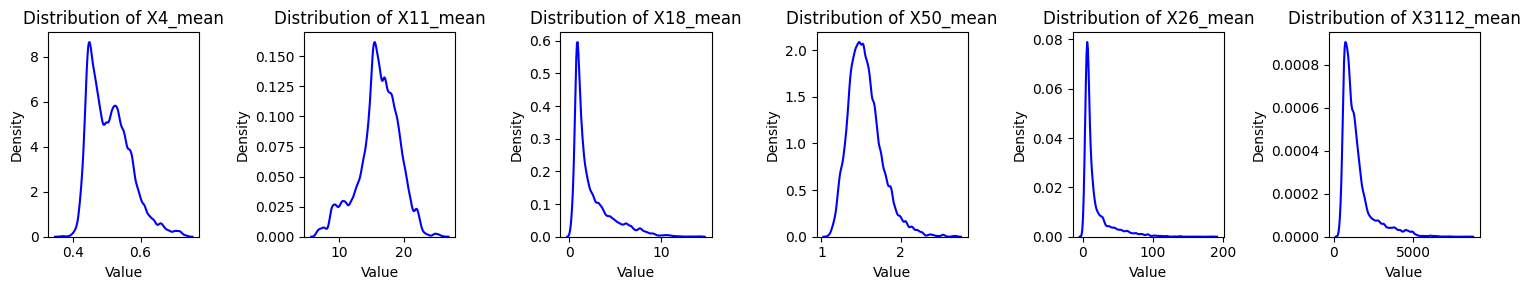

In [11]:
plot_data(plot_df)